In [93]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap
from matplotlib.colors import to_rgba


In [94]:
# Define the taxa level
taxa_level = 'Genus'

In [95]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_22102024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')
# metadata = metadata.set_index('SampleID')
metadata

,SampleID,c_zone,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_face,zone,sample_type,planned_study_day_of_visit,visual_assessment_in_vivo_number_of_inflammatory_lesions_face,day,subject_randomization_number,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_cheek_right,...,a,cohort,subject_randomization_id,class,subject_ID,subject_ID_CC,zone_CC,group,severity_level,severity_group
0,LAMI.RD308.D16.C1,C1,not applicable,Lesional,skin,Day 16,not applicable,16,308,not applicable,...,33.765638,acne,RD308,acne,PP_308,PP_308C1,Lesional_C1,Acne_L,moderate,moderate Acne_L
1,LAMI.RD310.D21.C1,C1,72,Lesional,skin,Day 21,36,21,310,17,...,31.919478,acne,RD310,acne,PP_310,PP_310C1,Lesional_C1,Acne_L,moderate,moderate Acne_L
2,LAMI.RD305.D21.C3,C3,69,Non-lesional,skin,Day 21,26,21,305,25,...,22.152503,acne,RD305,healthy,PP_305,PP_305C3,Non-lesional_C3,Acne_NL,absent,absent Acne_NL
3,LAMI.RD306.D18.C2,C2,not applicable,Lesional,skin,Day 18,not applicable,18,306,not applicable,...,27.397918,acne,RD306,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,low,low Acne_L
4,LAMI.RD306.D7.C2,C2,90,Lesional,skin,Day 7,13,7,306,23,...,28.819451,acne,RD306,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,moderate,moderate Acne_L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,LAMI.RD317.D21.C1,C1,77,Lesional,skin,Day 21,19,21,317,20,...,21.946648,acne,RD317,acne,PP_317,PP_317C1,Lesional_C1,Acne_L,low,low Acne_L
262,LAMI.RD001.D0.C1,C1,not applicable,Non-lesional,skin,Day 0,not applicable,0,1,not applicable,...,26.344240,control,RD001,healthy,PP_1,PP_1C1,Non-lesional_C1,Healthy,absent,absent Healthy
263,LAMI.RD014.D14.C2,C2,not applicable,Non-lesional,skin,Day 14,not applicable,14,14,not applicable,...,16.359699,control,RD014,healthy,PP_14,PP_14C2,Non-lesional_C2,Healthy,absent,absent Healthy
264,LAMI.RD314.D0.C1,C1,55,Lesional,skin,Day 0,31,0,314,16,...,22.494605,acne,RD314,acne,PP_314,PP_314C1,Lesional_C1,Acne_L,low,low Acne_L


In [96]:
V1V3_path = '../Data/16S/Tables/16S_V1-V3_Genus_collapsed.biom'
V4_path = '../Data/16S/Tables/16S_V4_Genus_collapsed.biom'

In [97]:
# Function to load BIOM table, collapse by taxa, sort rows by row sum, remove specified samples, and convert to relative abundance
def load_biom_table(biom_path, metadata_path, group):
    """
    Load BIOM table, filter by group, and return the DataFrame for the specified group.

    Parameters:
    - biom_path: Path to the BIOM file.
    - metadata_path: Path to the metadata file.
    - group: The group to filter on ('Healthy', 'Acne_NL', or 'Acne_L').

    Returns:
    - A DataFrame filtered by the specified group.
    """
    # Load metadata as a DataFrame from the file path
    metadata = pd.read_csv(metadata_path, sep='\t')

    # Load BIOM table and convert to a DataFrame
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Replace 'uncultured' row with 'uncultured Neisseriaceae' and others
    df = df.rename(index={' g__uncultured': ' g__uncultured Neisseriaceae'})
    df = df.rename(index={' g__Allorhizobium-Neorhizobium-Pararhizobium-Rhizobium': ' g__Allorhizobium'})

    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before proceeding
    df = df.drop(columns=['row_sum'])
    
    # Convert the table to relative abundances
    df = df.div(df.sum(axis=0), axis=1)
    
    # Filter metadata to keep only relevant sample IDs
    sample_groups = metadata[['SampleID', 'group']].set_index('SampleID')
    
    # Ensure the group is valid
    if group not in sample_groups['group'].unique():
        raise ValueError(f"Invalid group '{group}'. Choose from {sample_groups['group'].unique()}.")

    # Filter the BIOM DataFrame for the specified group
    group_df = df.loc[:, df.columns.isin(sample_groups[sample_groups['group'] == group].index)]
    
    return group_df


In [98]:
# Function to determine the top 15 taxon and collapse the rest as "Others"
def collapse_top_15(df):
    top_taxa = df.sum(axis=1).nlargest(15).index  # Select top 15 taxon
    df_top = df.loc[top_taxa]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_taxa)].sum()
    return df_top

In [99]:
# Predefined color palette for specific taxon
if taxa_level == "Family":
    taxa_colors = {
        ' f__Propionibacteriaceae': '#ffa505',  # Bright orange
        ' f__Mycobacteriaceae': '#70a8dc',      # Blue
        ' f__Streptococcaceae': '#92f0f0',      # Fluorescent light blue
        ' f__Porphyromonodaceae': '#e2b46c',    # Beige
        ' f__Bacteroidaceae': '#ffe59a',        # Pastel yellow
        ' f__Neisseriaceae': '#f6475f',         # Pinkish
        ' f__Moraxellaceae': '#c5bce0',         # Pastel purplish
        ' f__Marinomonadaceae': '#f4cccd',  # Light pink
        ' f__Celerinatantimonadaceae': '#bcbcbc',  # Light gray
        ' f__Alteromonadaceae': '#daead3',  # Pale mint green
        'Others': '#ededed'                 # White
    }
elif taxa_level == "Genus":
    taxa_colors = {
        ' g__Cutibacterium': '#ffa505',  # Bright orange
        # ' g__uncultured': '#808080',      # Grey
        ' g__uncultured Neisseriaceae': '#f6475f',         # Pinkish
        ' g__Staphylococcus': '#92f0f0',      # Fluorescent light blue
        ' g__Streptococcus': '#e2b46c',    # Beige
        ' g__Corynebacterium': '#ffe59a',        # Pastel yellow
        ' g__Lawsonella': '#70a8dc',         # Light blue
        ' g__Veillonella': '#c5bce0',         # Pastel purplish
        ' g__Micrococcus':'#f4cccd',           # Pastel yellow
        ' g__Alloprevotella': '#bcbcbc',        # Light gray
        ' g__Lactobacillus': '#daead3',     # Pale mint green
        ' g__Neisseria': '#f6475f',         # Redish pink
        'Others': '#ededed'                 # White
    }

In [100]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [101]:
# Function to get or assign colors to taxon
def get_taxa_colors(taxon, global_taxa_color_map):
    for taxa in taxon:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

In [102]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [103]:
# Define paths to the collapsed taxa tables
table_dict = {
    'V1-V3 Healthy': load_biom_table(V1V3_path, metadata_path, 'Healthy'),
    'V1-V3 Acne_NL': load_biom_table(V1V3_path, metadata_path, 'Acne_NL'),
    'V1-V3 Acne_L': load_biom_table(V1V3_path, metadata_path, 'Acne_L'),
    'V4 Healthy': load_biom_table(V4_path, metadata_path, 'Healthy'),
    'V4 Acne_NL': load_biom_table(V4_path, metadata_path, 'Acne_NL'),
    'V4 Acne_L': load_biom_table(V4_path, metadata_path, 'Acne_L')
}

In [104]:
metadata

,SampleID,c_zone,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_face,zone,sample_type,planned_study_day_of_visit,visual_assessment_in_vivo_number_of_inflammatory_lesions_face,day,subject_randomization_number,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_cheek_right,...,a,cohort,subject_randomization_id,class,subject_ID,subject_ID_CC,zone_CC,group,severity_level,severity_group
0,LAMI.RD308.D16.C1,C1,not applicable,Lesional,skin,Day 16,not applicable,16,308,not applicable,...,33.765638,acne,RD308,acne,PP_308,PP_308C1,Lesional_C1,Acne_L,moderate,moderate Acne_L
1,LAMI.RD310.D21.C1,C1,72,Lesional,skin,Day 21,36,21,310,17,...,31.919478,acne,RD310,acne,PP_310,PP_310C1,Lesional_C1,Acne_L,moderate,moderate Acne_L
2,LAMI.RD305.D21.C3,C3,69,Non-lesional,skin,Day 21,26,21,305,25,...,22.152503,acne,RD305,healthy,PP_305,PP_305C3,Non-lesional_C3,Acne_NL,absent,absent Acne_NL
3,LAMI.RD306.D18.C2,C2,not applicable,Lesional,skin,Day 18,not applicable,18,306,not applicable,...,27.397918,acne,RD306,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,low,low Acne_L
4,LAMI.RD306.D7.C2,C2,90,Lesional,skin,Day 7,13,7,306,23,...,28.819451,acne,RD306,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,moderate,moderate Acne_L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,LAMI.RD317.D21.C1,C1,77,Lesional,skin,Day 21,19,21,317,20,...,21.946648,acne,RD317,acne,PP_317,PP_317C1,Lesional_C1,Acne_L,low,low Acne_L
262,LAMI.RD001.D0.C1,C1,not applicable,Non-lesional,skin,Day 0,not applicable,0,1,not applicable,...,26.344240,control,RD001,healthy,PP_1,PP_1C1,Non-lesional_C1,Healthy,absent,absent Healthy
263,LAMI.RD014.D14.C2,C2,not applicable,Non-lesional,skin,Day 14,not applicable,14,14,not applicable,...,16.359699,control,RD014,healthy,PP_14,PP_14C2,Non-lesional_C2,Healthy,absent,absent Healthy
264,LAMI.RD314.D0.C1,C1,55,Lesional,skin,Day 0,31,0,314,16,...,22.494605,acne,RD314,acne,PP_314,PP_314C1,Lesional_C1,Acne_L,low,low Acne_L


In [111]:
def plot_per_sample_relative_abundance(df, metadata, output_dir, key, taxa_color_map, taxa_level='Genus'):
    """
    Plot per-sample relative abundance for microbiome data.

    Parameters:
    - df: DataFrame containing relative abundances with taxa as rows and samples as columns.
    - metadata: Metadata DataFrame containing 'SampleID', 'subject_ID', and 'group' columns.
    - output_dir: Directory to save output plots.
    - key: String to differentiate datasets (e.g., 'V1-V3 Healthy').
    - taxa_color_map: Dictionary mapping taxa to colors.
    - taxa_level: Taxonomic level for the plot title.
    """
    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{key}_{taxa_level}_per-sample_relative_abundance_plot.png')
    output_svg_file = os.path.join(output_dir, f'{key}_{taxa_level}_per-sample_relative_abundance_plot.svg')
    
    # Set plot title based on key
    key_map = {
        'V1-V3 Healthy': '16S rRNA V1-V3 Healthy Relative Abundance (n=47)',
        'V1-V3 Acne_NL': '16S rRNA V1-V3 Acne NL Relative Abundance (n=47)',
        'V1-V3 Acne_L': '16S rRNA V1-V3 Acne L Relative Abundance (n=142)',
        
        'V4 Healthy': '16S rRNA V4 Healthy Relative Abundance (n=27)',
        'V4 Acne_NL': '16S rRNA V4 Acne NL Relative Abundance (n=45)',
        'V4 Acne_L': '16S rRNA V4 Acne L Relative Abundance (n=145)'
    }
    plot_title = key_map.get(key, 'Relative Abundance')

    # Map custom x-axis labels
    metadata['x_tick_label'] = metadata['subject_ID'] + '_' + metadata['group']
    x_tick_labels = metadata.set_index('SampleID').loc[df.columns, 'x_tick_label']

    # Plot
    ax = df.T.plot(kind='bar', stacked=True, figsize=(12, 3),
                   width=0.8,  # Bars closer together
                   color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df.index])

    plt.ylabel('Relative Abundance', fontsize=18)
    # plt.xlabel('Samples', fontsize=16)
    plt.title(plot_title, fontsize=20)

    # Set x and y axis labels
    # plt.xticks(ticks=range(len(x_tick_labels)), labels=x_tick_labels, rotation=45, ha='right', fontsize=10)
    plt.xticks([], [])
    plt.yticks(fontsize=12)
    
    # Disable the legend
    plt.legend().set_visible(False)

    plt.tight_layout()

    # Save the plots
    plt.savefig(output_png_file, format='png', dpi=600)
    plt.savefig(output_svg_file, format='svg')
    plt.show()

    plt.close()


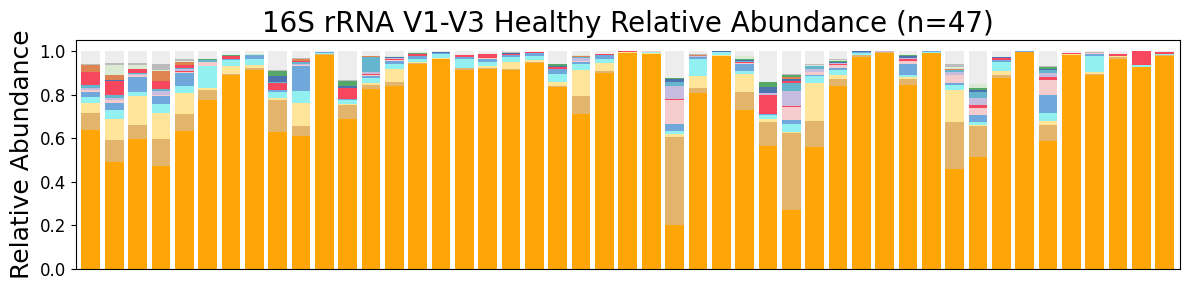

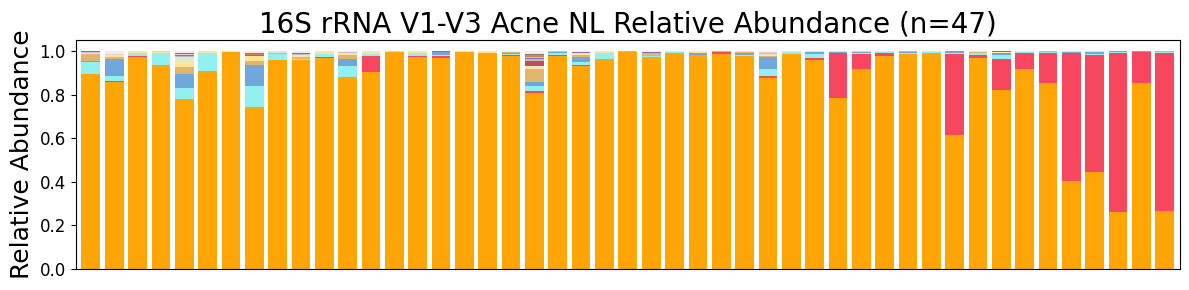

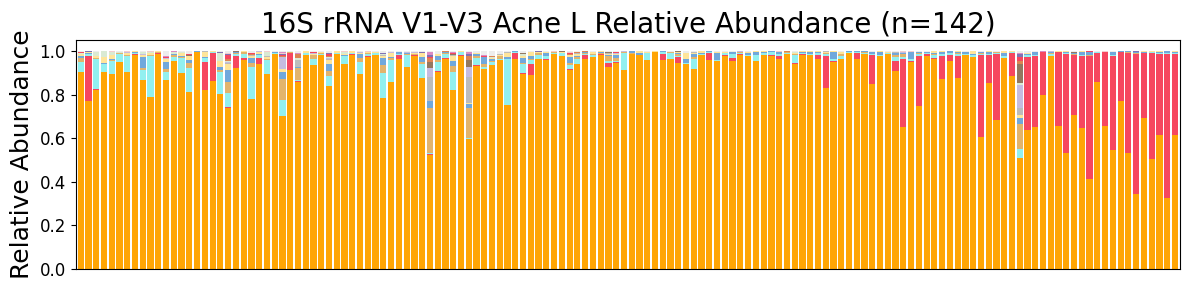

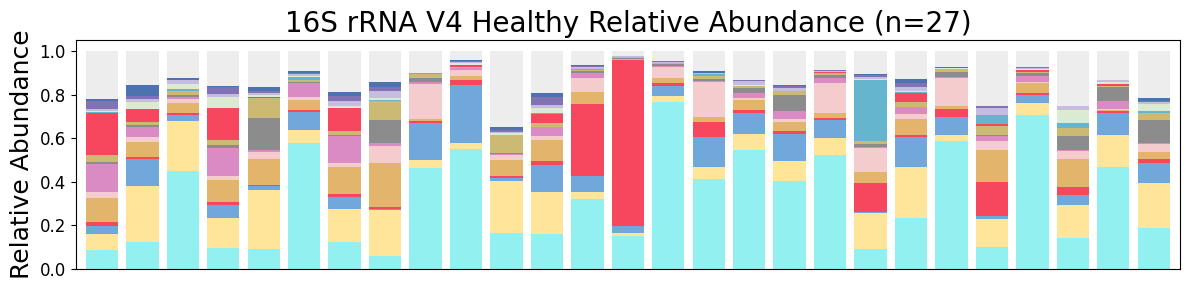

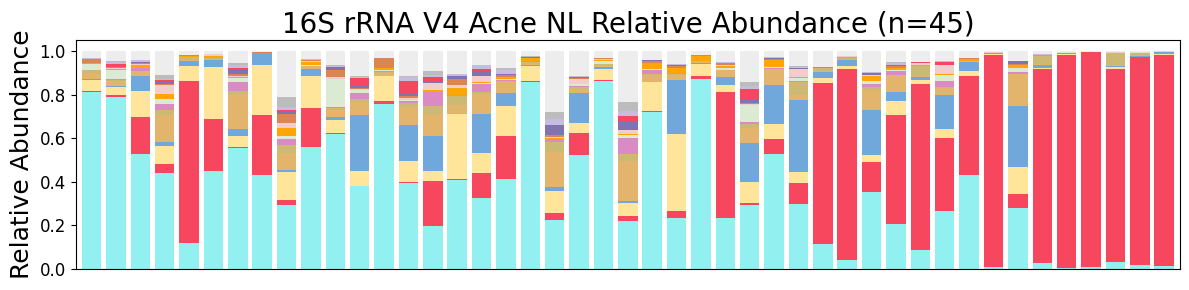

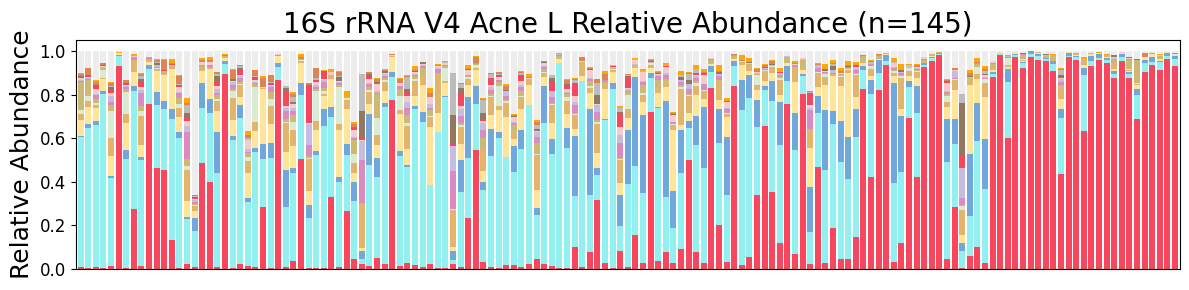

In [112]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to taxon across both datasets
for key, df in table_dict.items():
    df_top_15 = collapse_top_15(df)  # Now using the top 15 function
    
    # Define the output directory for the current key
    output_dir = '../Figures/16S_Figures/relative_abundance/'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    # metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top taxon in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_15.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_per_sample_relative_abundance(df_top_15, metadata, output_dir, key, global_taxa_color_map)